In [43]:
import sys
sys.path.append("../")

In [44]:
from src.strategies import naked_single,create_candidates, update_neighbors, hidden_single
from src.display import display_sudoku

In [63]:
import itertools
from collections import Counter

In [45]:
sudoku = [[0,8,0,6,1,0,0,0,4],
          [5,0,0,0,0,3,1,8,0],
          [0,0,0,0,0,0,9,0,0],
          [3,0,0,0,0,0,0,0,0],
          [0,0,6,0,0,0,0,2,5],
          [9,0,0,0,6,0,0,4,0],
          [0,5,1,3,0,9,7,0,0],
          [0,0,0,8,0,0,0,0,0],
          [4,0,0,0,0,0,0,0,0]]

In [46]:
candidates_matrix = create_candidates(sudoku) 

while True:
    # 1. Intentamos la técnica más sencilla (naked_single)
    if naked_single(sudoku, candidates_matrix):
        #display_sudoku(sudoku,candidates_matrix)
        continue  # Si hizo un cambio, volvemos a empezar por naked_single
    
    
    # 2. Si naked_single ya no encuentra nada, intentamos hidden_single
    if hidden_single(sudoku, candidates_matrix):
        #display_sudoku(sudoku,candidates_matrix)
        continue  # Si hidden_single hizo un cambio, volvemos a empezar por naked_single
    
    # 3. Si ninguno de los dos hizo cambios, es que el Sudoku se ha estancado
    break

In [69]:
def get_unit_coords(unit_type, index):
    """
    Devuelve una lista de 9 tuplas (fila, columna) para la unidad especificada.
    
    :param unit_type: 'row', 'column' o 'box'
    :param index: número de la unidad (0-8)
    """
    coords = []
    
    if unit_type == "row":
        coords = [(index, c) for c in range(9)]
        
    elif unit_type == "column":
        coords = [(r, index) for r in range(9)]
        
    elif unit_type == "box":
        # Calcula la fila y columna inicial del bloque 3x3
        # index 0: bloque superior izquierdo, index 8: inferior derecho
        start_row = (index // 3) * 3
        start_col = (index % 3) * 3
        coords = [(start_row + r, start_col + c) for r in range(3) for c in range(3)]
        
    return coords

In [73]:
from itertools import combinations

def find_naked_subset(candidates_matrix, n=2):
    """
    n=2 para Naked Pairs, n=3 para Naked Triples.
    Busca celdas en la misma unidad (fila/columna/bloque) cuyos 
    candidatos formen un subset del mismo tamaño n.
    """
    for unit_type in ["row", "column", "box"]:
        for i in range(9):
            coords = get_unit_coords(unit_type, i)
            
            # FILTRADO CORREGIDO:
            # Seleccionamos solo las celdas que son 'set' y tienen entre 2 y 'n' candidatos
            candidate_cells = []
            for r, c in coords:
                cell_data = candidates_matrix[r][c]
                if isinstance(cell_data, set) and 1 < len(cell_data) <= n:
                    candidate_cells.append((r, c))
            
            # Buscar combinaciones de 'n' celdas dentro de esta unidad
            if len(candidate_cells) >= n:
                for subset in combinations(candidate_cells, n):
                    # Unir los sets de estas n celdas
                    combined_candidates = set().union(*(candidates_matrix[r][c] for r, c in subset))
                    
                    # Si la unión tiene exactamente tamaño 'n', hemos encontrado un Naked Subset
                    if len(combined_candidates) == n:
                        # ELIMINACIÓN:
                        # Limpiamos esos candidatos de las otras celdas de la misma unidad
                        modified = False
                        for r, c in coords:
                            if (r, c) not in subset:
                                # Comprobamos si hay algo que borrar para no marcar cambios falsos
                                if candidates_matrix[r][c] & combined_candidates:
                                    candidates_matrix[r][c] -= combined_candidates
                                    modified = True
                        
                        if modified:
                            return True # Retornamos True al primer cambio para actualizar y volver a buscar
    return False

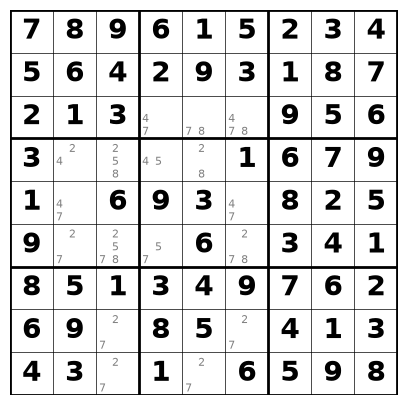

In [71]:
display_sudoku(sudoku,candidates_matrix)

In [74]:
find_naked_subset(sudoku)

False

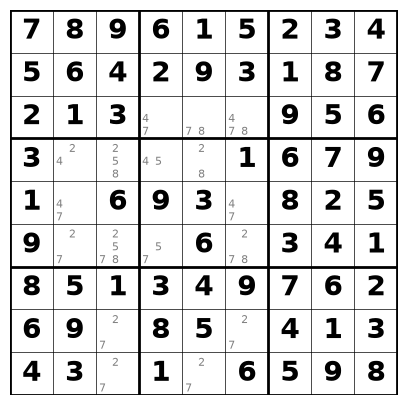

In [75]:
display_sudoku(sudoku,candidates_matrix)

In [72]:
candidates_matrix

[[set(), set(), set(), set(), set(), set(), set(), set(), set()],
 [set(), set(), set(), set(), set(), set(), set(), set(), set()],
 [set(), set(), set(), {4, 7}, {7, 8}, {4, 7, 8}, set(), set(), set()],
 [set(), {2, 4}, {2, 5, 8}, {4, 5}, {2, 8}, set(), set(), set(), set()],
 [set(), {4, 7}, set(), set(), set(), {4, 7}, set(), set(), set()],
 [set(), {2, 7}, {2, 5, 7, 8}, {5, 7}, set(), {2, 7, 8}, set(), set(), set()],
 [set(), set(), set(), set(), set(), set(), set(), set(), set()],
 [set(), set(), {2, 7}, set(), set(), {2, 7}, set(), set(), set()],
 [set(), set(), {2, 7}, set(), {2, 7}, set(), set(), set(), set()]]